# installing dependencies

In [ ]:
!pip install -q emoji
!pip install -q PyArabic
!pip install -q arabert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 9.5 MB/s eta 0:00:00


In [ ]:
import torch

# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))
    !nvidia-smi

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

No GPU available, using the CPU instead.


# Creating training datasets

In [ ]:
import pandas as pd
import numpy as np
from typing import List
from tqdm import tqdm_notebook as tqdm
from sklearn.model_selection import train_test_split

This custom dataset class will help us hold our datasets in a structred manner.
It's not necessary to use it with your own data

In [ ]:
class CustomDataset:
    def __init__(
        self,
        name: str,
        train: List[pd.DataFrame],
        val: List[pd.DataFrame],
        test: List[pd.DataFrame],
        label_list: List[str],
    ):
        """Class to hold and structure datasets.

        Args:

        name (str): holds the name of the dataset so we can select it later
        train (List[pd.DataFrame]): holds training pandas dataframe with 2 columns ["text","label"]
        val (List[pd.DataFrame]): holds validation pandas dataframe with 2 columns ["text","label"]
        test (List[pd.DataFrame]): holds testing pandas dataframe with 2 columns ["text","label"]
        label_list (List[str]): holds the list  of labels
        """
        self.name = name
        self.train = train
        self.val = val
        self.test = test
        self.label_list = label_list

In [ ]:
# This will hold all the downloaded and structred datasets
all_datasets= []
DATA_COLUMN = "text"
LABEL_COLUMN = "Final Label"

You can choose which ever dataset you like or use your own.
At this stage we don't do any preprocessing on the text, this is done later when loading the text.

## Climate Data

In [ ]:
data = pd.read_excel('All Climate Change Data - All Related.xlsx')

data.drop_duplicates(subset='text', inplace = True)
data.dropna(inplace = True, subset='text')
data.reset_index(drop=True, inplace = True)

data = data.rename(columns={'sentiment':'Final Label'})

data = data[['text', 'Final Label']]
data['Final Label'] = data['Final Label'].str.lower()
data.columns = [DATA_COLUMN, LABEL_COLUMN]
print(data[LABEL_COLUMN].value_counts())

Final Label
neutral     10307
negative     8140
positive     5510
Name: count, dtype: int64


In [ ]:
data.shape

(23957, 2)

In [ ]:
print(data[LABEL_COLUMN].value_counts())

Final Label
neutral     10307
negative     8140
positive     5510
Name: count, dtype: int64


In [ ]:
data[DATA_COLUMN] = data[DATA_COLUMN].str.replace(r'[^\w\s]+', '')
data[DATA_COLUMN] = data[DATA_COLUMN].str.replace("\s+", " ", regex=True)

In [ ]:
import string
import re

arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:"؟.,'{}~¦+|!”…“–ـ'''
english_punctuations = string.punctuation
punctuations_list = arabic_punctuations + english_punctuations

def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("گ", "ك", text)
    return text

data[DATA_COLUMN] = data[DATA_COLUMN].apply(normalize_arabic)

data.head()

,text,Final Label
0,هذه ال٢.٥٪ لا تنطلق الى الفضاء الكوني فتحتبس و...,negative
1,#عاجل | ادارة الكوارث والطوارئ التركية: ازالة ...,neutral
2,RT @USUN: عُقد في مالطا هذا الاسبوع اول اجتماع...,neutral
3,رغم ارتفاع درجات الحرارة واشعة الشمس اللاهبة و...,positive
4,قبل ايام تم استضافتي لتسجيل بودكاست بحكم اختصا...,neutral


In [ ]:
def data_cleaning(text):
    """Clean and preprocess text data.
    Args:
        text (pd.Series): A pandas Series containing text data to be cleaned.
    Returns:
        pd.Series: A pandas Series with the cleaned text data.

    Cleaning Steps:
    - Removes emojis and special characters like '\x89Û_', '&amp', etc.
    - Replaces consecutive dots with an empty string.
    - Removes '#' symbol from text.
    - Removes user names starting with '@'.
    - Removes URLs starting with 'http' or 'https'.
    - Remove diacritics.
    - Remove English.
    - Removes extra whitespaces between words.

    """
    clean = text
    # Replace consecutive dots with an empty string
    pattern = re.compile('\\.+?(?=\B|$)')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=''))
    # Replace '\x89Û_' with a whitespace
    pattern = re.compile('\x89Û_')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=' '))
    # Replace newline characters with a whitespace
    pattern = re.compile('\\n')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=' '))
    # Remove '#' symbol from text
    clean = clean.apply(lambda r: r.replace('#', ''))
    # Remove '_' symbol from text
    pattern = re.compile('_')
    clean = clean.apply(lambda r: re.sub(pattern, ' ', r))
    # Replace user names with '@'
    pattern = re.compile('@[a-zA-Z0-9\_]+')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl='@'))
    # Remove URLs
    pattern = re.compile('https?\S+(?=\s|$)')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl='www'))
    # Remove emojis
    clean = clean.apply(lambda r: emoji.replace_emoji(r, replace=""))
    # Remove diacritics
    clean = clean.apply(lambda r: araby.strip_diacritics(r))
    # Remove English
    pattern = re.compile(r'[a-zA-Z]+')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=''))
    # Remove extra whitespaces
    clean = clean.apply(lambda r: ' '.join(r.split()))  # Remove extra whitespaces between words

    return clean

In [ ]:
import re
import pyarabic.araby as araby
data[DATA_COLUMN] = data_cleaning(data[DATA_COLUMN])

In [ ]:
def remove_ids(text):
  return text.split("—")[0].strip()

data[DATA_COLUMN] = data[DATA_COLUMN].apply(remove_ids)

In [ ]:
data.dropna(inplace = True)
data = data.drop_duplicates(subset = DATA_COLUMN)

In [ ]:
indecies = pd.read_csv('Train-Val-Test-Indecies-Climate.csv')

# Clean and convert to integer index arrays
test = data.loc[indecies['test'].dropna().astype(int).values]
train1 = data.loc[indecies['train'].dropna().astype(int).values]
val1 = data.loc[indecies['val'].dropna().astype(int).values]

In [ ]:
train1.shape

(16769, 2)

# Load SemEval

In [ ]:
semeval = pd.read_csv('SemEval2017-task4-train.subtask-A.arabic.txt', delimiter='\t', header=None, names=['id', 'sentiment', 'text'])
semeval = semeval[['text', 'sentiment']]
semeval = semeval.rename(columns={'sentiment':'Final Label'})

semeval.head()

,text,Final Label
0,إجبار أبل على التعاون على فك شفرة اجهزتها http...,positive
1,RT @20fourMedia: #غوغل تتحدى أبل وأمازون بأجهز...,positive
2,جوجل تنافس أبل وسامسونج بهاتف جديد https://t.c...,positive
3,رئيس شركة أبل: الواقع المعزز سيصبح أهم من الطع...,positive
4,ساعة أبل في الأسواق مرة أخرى https://t.co/dY2x...,neutral


In [ ]:
semeval['text'] = semeval['text'].str.replace(r'[^\w\s]+', '')
semeval['text'] = semeval['text'].str.replace("\s+", " ", regex=True)

semeval['text'] = semeval['text'].apply(normalize_arabic)

semeval['text'] = data_cleaning(semeval['text'])
semeval['text'] = semeval['text'].apply(remove_ids)

semeval.dropna(inplace = True)
semeval = semeval.drop_duplicates(subset = 'text')

In [ ]:
testsem, trainsem = train_test_split(semeval,
                               test_size=1000,
                               stratify=semeval[LABEL_COLUMN],
                               random_state=42)

In [ ]:
ad_semeval = pd.read_excel('/content/Additional Training Exp 1 SemEval (Whole).xlsx')
ad_semeval = ad_semeval.reindex(semeval.index)

ad_semeval2 = pd.read_excel('/content/Additional Training Exp 1 SemEval (Whole).xlsx')
ad_semeval['text'] = ad_semeval2['text'].values
ad_semeval['Final Prediction'] = ad_semeval2['Final Prediction'].values
ad_semeval['true'] = ad_semeval2['true'].values

ad_semeval = ad_semeval.loc[testsem.index.values]

ad_semeval.to_excel('Additional Training Exp 1 SemEval.xlsx', index = False)
ad_semeval.shape[0]

2281

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Load ASTD

In [ ]:
import pandas as pd

# Read the .txt file (comma, tab, or custom-delimited)
df = pd.read_csv('Tweets.txt', delimiter='\t', header=None, names=['text', 'Label'])  # Change delimiter if needed
df.head()

,text,Label
0,بعد استقالة رئيس #المحكمة_الدستورية ننتظر استق...,OBJ
1,أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر...,POS
2,البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام ال...,NEG
3,#الحرية_والعدالة | شاهد الآن: #ليلة_الاتحادية ...,OBJ
4,الوالدة لو اقولها بخاطري حشيشة تضحك بس من اقول...,NEUTRAL


In [ ]:
df = df[df['Label']!='OBJ']
df['Label'] = df['Label'].map({
    'NEG': 'negative',
    'NEUTRAL': 'neutral',
    'POS': 'positive'
})
df.head()

df = df.rename(columns={'Label':'Final Label'})
df.head()

,text,Final Label
1,أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر...,positive
2,البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام ال...,negative
4,الوالدة لو اقولها بخاطري حشيشة تضحك بس من اقول...,neutral
5,#انتخبوا_العرص #انتخبوا_البرص #مرسى_رئيسى #اين...,neutral
6,امير عيد هو اللي فعلا يتقال عليه ستريكر صريح #...,positive


In [ ]:
df['text'] = df['text'].str.replace(r'[^\w\s]+', '')
df['text'] = df['text'].str.replace("\s+", " ", regex=True)

df['text'] = df['text'].apply(normalize_arabic)

df['text'] = data_cleaning(df['text'])
df['text'] = df['text'].apply(remove_ids)

df.dropna(inplace = True)
df = df.drop_duplicates(subset = 'text')

In [ ]:
testastd, trainastd = train_test_split(df,
                               test_size=1000,
                               stratify=df[LABEL_COLUMN],
                               random_state=42)

# Load ASAD data

In [ ]:
asad = pd.read_csv('train_all.csv')
asad = asad.rename(columns={'Text':DATA_COLUMN, 'sentiment':LABEL_COLUMN})
# asad[LABEL_COLUMN] = asad[LABEL_COLUMN].str.title()

asad[DATA_COLUMN] = asad[DATA_COLUMN].str.replace(r'[^\w\s]+', '')
asad[DATA_COLUMN] = asad[DATA_COLUMN].str.replace("\s+", " ", regex=True)

asad[DATA_COLUMN] = asad[DATA_COLUMN].apply(normalize_arabic)

asad[DATA_COLUMN] = data_cleaning(asad[DATA_COLUMN])
asad[DATA_COLUMN] = asad[DATA_COLUMN].apply(remove_ids)

In [ ]:
ind = pd.read_excel('/content/Used ASAD For Training.xlsx')

previous_trained = asad.loc[ind['Unnamed: 0'].values]
previous_trained = previous_trained[[DATA_COLUMN, LABEL_COLUMN]]

previous_trained.columns = [DATA_COLUMN, LABEL_COLUMN]
previous_trained = previous_trained.reset_index(drop = True)
print(previous_trained[LABEL_COLUMN].value_counts())

Final Label
neutral     16289
negative     3890
positive     3778
Name: count, dtype: int64


In [ ]:
new = asad.drop(index=ind['Unnamed: 0'].values)
print(new.shape[0])
new.dropna(inplace = True)
new.drop_duplicates(subset = DATA_COLUMN, inplace = True)
print(new.shape[0])

31043
30145


In [ ]:
temp, train2 = train_test_split(new,
                               test_size=1000,
                               stratify=new[LABEL_COLUMN],
                               random_state=42)

remove, val2 = train_test_split(temp,
                               test_size=1000,
                               stratify=temp[LABEL_COLUMN],
                               random_state=42)

In [ ]:
train = pd.concat([train1, train2, trainsem, trainastd])
val = pd.concat([val1, val2])

In [ ]:
label_list = ['negative', 'neutral', 'positive']

data = CustomDataset("Climate", train, val, test, label_list)
all_datasets.append(data)

# Trainer

Start the training procedure

In [ ]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import copy

from arabert.preprocess import ArabertPreprocessor
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score)
from torch.utils.data import DataLoader, Dataset
from transformers import (AutoConfig, AutoModelForSequenceClassification,
                          AutoTokenizer, BertTokenizer, Trainer,
                          TrainingArguments)
from transformers.data.processors.utils import InputFeatures

List all the datasets we have

In [ ]:
for x in all_datasets:
  print(x.name)

Climate


In [ ]:
# select a dataset
dataset_name = 'Climate'
model_name = 'aubmindlab/bert-base-arabertv02-twitter'

In [ ]:
for d in all_datasets:
  if d.name==dataset_name:
    selected_dataset = copy.deepcopy(d)
    print('Dataset found')
    break

Dataset found


Create and apply preprocessing using the AraBERT processor

In [ ]:
arabic_prep = ArabertPreprocessor(model_name)

selected_dataset.train[DATA_COLUMN] = selected_dataset.train[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))
selected_dataset.val[DATA_COLUMN] = selected_dataset.val[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))
selected_dataset.test[DATA_COLUMN] = selected_dataset.test[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))

In [ ]:
# Sanity check on the dataset
list(selected_dataset.train[DATA_COLUMN][0:10])

['الانسان المثقف والانسان العادي الانسان المثقف محمل حالو هموم الدني ومفكر حالو بيقدر يسكر ثقب الاوزون ، الانسان العادي ولا على بالو عايش ومرتاح',
 'اعتدال ونشاط في سرعة الرياح الشمالية الغربية مع غبار مثار في المناطق البرية والمكشوفة اليوم الاربعاء وغدا الخميس وارتفاع الامواج في البحر والطقس جاف مع ارتفاع درجات الحرارة العظمى نهار اليوم في شمال شرق السعودية والكويت',
 'ابناء ورجالات تبوك بتكاتفهم وتكاتف مؤسسات المجتمع المدني باستطاعتهم جعل تبوك الورد اسم على مسمى تطوع ابناء تبوك لمكافحة التصحر',
 'كونا : مسؤول بيئي عربي : مؤتمر التصحر بانقرة يسلط الضوء على تخفيف تدهور الاراضي',
 'قضية تغير المناخ وقضية الاوبئة هما الاولتان عالميا بالتبادل فى اهتمام الدول الكبرى الراعية لارتفاع درجة الحرارة والراعية للتلوث والراعية للحرب الفيروسية',
 'الصين تواجه ازمة الطاقة بقرارات صعبة : منها رفع اسعار الطاقة ولكن اهم قرار : ارسال الاوامر الى مناجم الفحم " انتجوا ما تستطيعون انتاجه من الفحم " يعنى توجه الصين لحل ازمةالطاقة : انتاج مزيد من الفحم وليذهب المناخ وتغيراته الى الجحيم وتعد الصين من اكبر دول

Now we need to check the tokenized sentence length to decide on the maximum sentence length value

In [ ]:
tok = AutoTokenizer.from_pretrained(model_name)

Training Sentence Lengths: 


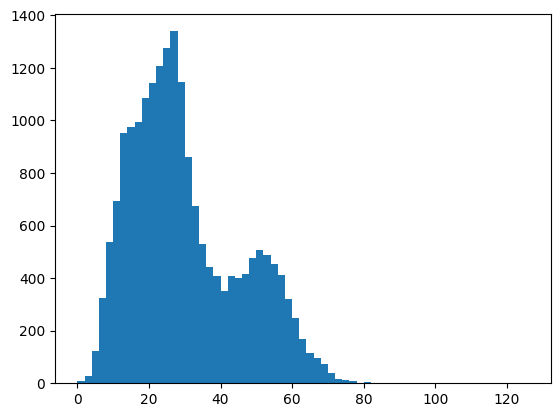

Testing Sentence Lengths: 


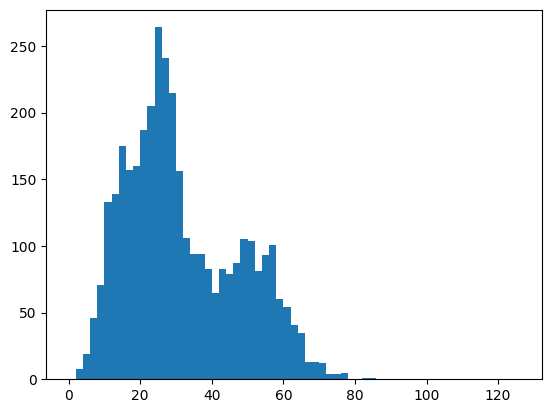

In [ ]:
print("Training Sentence Lengths: ")
plt.hist([ len(tok.tokenize(sentence)) for sentence in selected_dataset.train[DATA_COLUMN].to_list()],bins=range(0,128,2))
plt.show()

print("Testing Sentence Lengths: ")
plt.hist([ len(tok.tokenize(sentence)) for sentence in selected_dataset.test[DATA_COLUMN].to_list()],bins=range(0,128,2))
plt.show()

Let's select 100 as our maximum sentence length, and check how many sequences will be truncated

In [ ]:
max_len = 128

In [ ]:
print("Truncated training sequences: ", sum([len(tok.tokenize(sentence)) > max_len for sentence in selected_dataset.test[DATA_COLUMN].to_list()]))

print("Truncated testing sequences: ", sum([len(tok.tokenize(sentence)) > max_len for sentence in selected_dataset.test[DATA_COLUMN].to_list()]))

Truncated training sequences:  0
Truncated testing sequences:  0


8 out of ~4000 for testing isn't bad

Now let's create a classification dataset to load the data

In [ ]:
class ClassificationDataset(Dataset):
    def __init__(self, text, target, model_name, max_len, label_map):
      super(ClassificationDataset).__init__()
      """
      Args:
      text (List[str]): List of the training text
      target (List[str]): List of the training labels
      tokenizer_name (str): The tokenizer name (same as model_name).
      max_len (int): Maximum sentence length
      label_map (Dict[str,int]): A dictionary that maps the class labels to integer
      """
      self.text = text
      self.target = target
      self.tokenizer_name = model_name
      self.tokenizer = AutoTokenizer.from_pretrained(model_name)
      self.max_len = max_len
      self.label_map = label_map


    def __len__(self):
      return len(self.text)

    def __getitem__(self,item):
      text = str(self.text[item])
      text = " ".join(text.split())

      inputs = self.tokenizer(
          text,
          max_length=self.max_len,
          padding='max_length',
          truncation=True
      )
      return InputFeatures(**inputs,label=self.label_map[self.target[item]])

In [ ]:
label_map = { v:index for index, v in enumerate(selected_dataset.label_list) }
print(label_map)

train_dataset = ClassificationDataset(
    selected_dataset.train[DATA_COLUMN].to_list(),
    selected_dataset.train[LABEL_COLUMN].to_list(),
    model_name,
    max_len,
    label_map
  )
val_dataset = ClassificationDataset(
    selected_dataset.val[DATA_COLUMN].to_list(),
    selected_dataset.val[LABEL_COLUMN].to_list(),
    model_name,
    max_len,
    label_map
  )

{'negative': 0, 'neutral': 1, 'positive': 2}


Check the dataset output

In [ ]:
print(next(iter(train_dataset)))

InputFeatures(input_ids=[2, 4199, 8088, 49075, 10850, 4199, 8088, 27938, 1050, 185, 15903, 37901, 12208, 435, 1050, 185, 1268, 2394, 1287, 435, 41400, 32254, 319, 103, 4199, 10850, 662, 323, 15665, 17906, 16708, 571, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], attention_mask=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], token_type_ids=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

Create a function that return a pretrained model ready to do classification

In [ ]:
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(model_name, return_dict=True, num_labels=len(label_map))

Define whatever metric you want here

In [ ]:
def compute_metrics(p): #p should be of type EvalPrediction
  preds = np.argmax(p.predictions, axis=1)
  assert len(preds) == len(p.label_ids)
  macro_f1 = f1_score(p.label_ids,preds,average='macro')
  macro_precision = precision_score(p.label_ids,preds,average='macro')
  macro_recall = recall_score(p.label_ids,preds,average='macro')
  acc = accuracy_score(p.label_ids,preds)
  return {
      'macro_f1' : macro_f1,
      'macro_precision' : macro_precision,
      'macro_recall' : macro_recall,
      'accuracy': acc
  }

In [ ]:
def set_seed(seed=42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic=True
  torch.backends.cudnn.benchmark = False

#Regular Training

Define our training parameters.
Check the TrainingArguments documentation for more options https://huggingface.co/transformers/main_classes/trainer.html#trainingarguments

In [ ]:
training_args = TrainingArguments(
    output_dir= "./train",
    adam_epsilon = 1e-8,
    learning_rate = 2e-5,
    fp16 = False, # enable this when using V100 or T4 GPU
    per_device_train_batch_size = 32, # up to 64 on 16GB with max len of 128
    per_device_eval_batch_size = 128,
    gradient_accumulation_steps = 2, # use this to scale batch size without needing more memory
    num_train_epochs= 3,
    warmup_ratio = 0,
    do_eval = True,
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    load_best_model_at_end = True, # this allows to automatically get the best model at the end based on whatever metric we want
    metric_for_best_model = 'macro_f1',
    greater_is_better = True,
    seed = 25,
    report_to = 'none'
  )

set_seed(training_args.seed)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Create the trainer

In [ ]:
trainer = Trainer(
    model = model_init(),
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
#start the training
trainer.train()

Save the model, the tokenizer and the config

In [ ]:
inv_label_map = inv_label_map = { v:k for k, v in label_map.items()}
print(inv_label_map)
trainer.model.config.label2id = label_map
trainer.model.config.id2label = inv_label_map
dir = '/content/drive/MyDrive/Additional_tuning-WholeData'
trainer.save_model(dir)
train_dataset.tokenizer.save_pretrained(dir)

## predict using the saved model

In [ ]:
from transformers import pipeline
import more_itertools

In [ ]:
pred_df = pd.DataFrame()
pred_df['text'] = selected_dataset.test[DATA_COLUMN].values

In [ ]:
pipe = pipeline("sentiment-analysis", model=dir, device=0, return_all_scores =True, max_length=max_len, truncation=True)
preds = []
for s in tqdm(more_itertools.chunked(list(pred_df['text']), 32)): # batching for faster inference
    preds.extend(pipe(s))
pred_df[f'preds'] = preds

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/tmp/ipykernel_3403/4288232190.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for s in tqdm(more_itertools.chunked(list(pred_df['text']), 32)): # batching for faster inference


0it [00:00, ?it/s]

In [ ]:
final_pred = []
for prediction in pred_df['preds']:
  final_pred.append(prediction['label'])

pred_df[f'Final Prediction'] = final_pred
pred_df[f'Final Prediction'].value_counts()

,count
Final Prediction,
neutral,1378
negative,1283
positive,933


In [ ]:
print(classification_report(pred_df['True Label'].str.lower(),pred_df['Final Prediction'], digits=4))

              precision    recall  f1-score   support

    negative     0.7560    0.7944    0.7748      1221
     neutral     0.7388    0.6585    0.6963      1546
    positive     0.7310    0.8247    0.7750       827

    accuracy                         0.7429      3594
   macro avg     0.7419    0.7592    0.7487      3594
weighted avg     0.7428    0.7429    0.7411      3594



# Pred on Asad

In [ ]:
remove.shape

(28145, 3)

In [ ]:
indecies = pd.read_csv('Train-Val-Test-Indecies-Climate-ASAD.csv')

# Clean and convert to integer index arrays
test = previous_trained.loc[indecies['test'].dropna().astype(int).values]

In [ ]:
pred_asad = pd.DataFrame()
pred_asad['text'] = test['text'].values

pipe = pipeline("sentiment-analysis", model=dir, device=0, return_all_scores =True, max_length=max_len, truncation=True)

preds = []
for s in tqdm(more_itertools.chunked(list(pred_asad['text']), 32)): # batching for faster inference
    preds.extend(pipe(s))
pred_asad[f'preds'] = preds

final_pred = []
for prediction in pred_asad['preds']:
  final_pred.append(prediction['label'])

pred_asad[f'Final Prediction'] = final_pred
pred_asad[f'Final Prediction'].value_counts()

,count
Final Prediction,
neutral,2119
negative,740
positive,735


In [2]:
print('Macro Average Scores')
pre = precision_score(test['Final Label'],pred_asad['Final Prediction'], average = 'macro')
print(f'Precision = {pre:.3f}')
recall = recall_score(test['Final Label'],pred_asad['Final Prediction'], average = 'macro')
print(f'Recall = {recall:.3f}')
f1 = f1_score(test['Final Label'],pred_asad['Final Prediction'], average = 'macro')
print(f'F1 score = {f1:.3f}')

print('Weighted Average Scores')
pre = precision_score(test['Final Label'],pred_asad['Final Prediction'], average = 'weighted')
print(f'Precision = {pre:.3f}')
recall = recall_score(test['Final Label'],pred_asad['Final Prediction'], average = 'weighted')
print(f'Recall = {recall:.3f}')
f1 = f1_score(test['Final Label'],pred_asad['Final Prediction'], average = 'weighted')
print(f'F1 score = {f1:.3f}')

Macro Average Scores
Precision = 0.655
Recall = 0.716
F1 score = 0.679
Weighted Average Scores
Precision = 0.763
Recall = 0.737
F1 score = 0.747


# ASTD

In [ ]:
import pandas as pd

# Read the .txt file (comma, tab, or custom-delimited)
df = pd.read_csv('Tweets.txt', delimiter='\t', header=None, names=['text', 'Label'])  # Change delimiter if needed
df.head()

,text,Label
0,بعد استقالة رئيس #المحكمة_الدستورية ننتظر استق...,OBJ
1,أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر...,POS
2,البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام ال...,NEG
3,#الحرية_والعدالة | شاهد الآن: #ليلة_الاتحادية ...,OBJ
4,الوالدة لو اقولها بخاطري حشيشة تضحك بس من اقول...,NEUTRAL


In [ ]:
df = df[df['Label']!='OBJ']
df['Label'] = df['Label'].map({
    'NEG': 'Negative',
    'NEUTRAL': 'Neutral',
    'POS': 'Positive'
})
df.head()

,text,Label
1,أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر...,Positive
2,البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام ال...,Negative
4,الوالدة لو اقولها بخاطري حشيشة تضحك بس من اقول...,Neutral
5,#انتخبوا_العرص #انتخبوا_البرص #مرسى_رئيسى #اين...,Neutral
6,امير عيد هو اللي فعلا يتقال عليه ستريكر صريح #...,Positive


In [ ]:
pred_df = pd.DataFrame()
pred_df['text'] = testastd['text'].values

pipe = pipeline("sentiment-analysis", model=dir, device=0, return_all_scores =True, max_length=max_len, truncation=True)

preds = []
for s in tqdm(more_itertools.chunked(list(pred_df['text']), 32)): # batching for faster inference
    preds.extend(pipe(s))
pred_df[f'preds'] = preds

final_pred = []
for prediction in pred_df['preds']:
  final_pred.append(prediction['label'])

pred_df[f'Final Prediction'] = final_pred
pred_df[f'Final Prediction'].value_counts()

,count
Final Prediction,
negative,1100
neutral,660
positive,463


In [ ]:
print(classification_report(testastd['Final Label'],pred_df['Final Prediction'], digits=4))

              precision    recall  f1-score   support

    negative     0.7718    0.7500    0.7608      1132
     neutral     0.4333    0.5153    0.4708       555
    positive     0.8099    0.6996    0.7508       536

    accuracy                         0.6793      2223
   macro avg     0.6717    0.6550    0.6608      2223
weighted avg     0.6965    0.6793    0.6859      2223



# SemEval

In [ ]:
pred_semeval = pd.DataFrame()
pred_semeval['text'] = testsem['text'].values

pipe = pipeline("sentiment-analysis", model=dir, device=0, return_all_scores =True, max_length=max_len, truncation=True)

preds = []
for s in tqdm(more_itertools.chunked(list(pred_semeval['text']), 32)): # batching for faster inference
    preds.extend(pipe(s))
pred_semeval[f'preds'] = preds

final_pred = []
for prediction in pred_semeval['preds']:
  final_pred.append(prediction['label'])

pred_semeval[f'Final Prediction'] = final_pred
pred_semeval[f'Final Prediction'].value_counts()

,count
Final Prediction,
neutral,1098
negative,723
positive,460


In [ ]:
print(classification_report(testsem['Final Label'],pred_semeval['Final Prediction'], digits=4))

              precision    recall  f1-score   support

    negative     0.7898    0.7464    0.7675       765
     neutral     0.6821    0.7423    0.7110      1009
    positive     0.6978    0.6331    0.6639       507

    accuracy                         0.7194      2281
   macro avg     0.7232    0.7073    0.7141      2281
weighted avg     0.7217    0.7194    0.7195      2281



In [ ]:
pipe = pipeline("sentiment-analysis", model=dir, device=0, return_all_scores =True, max_length=max_len, truncation=True)

preds = []
for s in tqdm(more_itertools.chunked(list(semeval['text']), 32)): # batching for faster inference
    preds.extend(pipe(s))
semeval[f'preds'] = preds

final_pred = []
for prediction in semeval['preds']:
  final_pred.append(prediction['label'])

semeval[f'Final Prediction'] = final_pred
semeval[f'Final Prediction'].value_counts()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/tmp/ipykernel_3403/2100035002.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for s in tqdm(more_itertools.chunked(list(semeval['text']), 32)): # batching for faster inference


0it [00:00, ?it/s]

,count
Final Prediction,
neutral,1518
negative,1066
positive,697


In [4]:
print('Macro Average Scores')
pre = precision_score(semeval['Final Label'],semeval['Final Prediction'], average = 'macro')
print(f'Precision = {0.724}')
recall = recall_score(semeval['Final Label'],semeval['Final Prediction'], average = 'macro')
print(f'Recall = {0.708}')
f1 = f1_score(semeval['Final Label'],semeval['Final Prediction'], average = 'macro')
print(f'F1 score = {0.715}')

print('Weighted Average Scores')
pre = precision_score(semeval['Final Label'],semeval['Final Prediction'], average = 'weighted')
print(f'Precision = {0.722}')
recall = recall_score(semeval['Final Label'],semeval['Final Prediction'], average = 'weighted')
print(f'Recall = {0.720}')
f1 = f1_score(semeval['Final Label'],semeval['Final Prediction'], average = 'weighted')
print(f'F1 score = {0.720}')

Macro Average Scores
Precision = 0.724
Recall = 0.708
F1 score = 0.715
Weighted Average Scores
Precision = 0.722
Recall = 0.72
F1 score = 0.72
